In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import scatter
from numpy.random import logistic
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
#if file exist and if read it will return data

import os

for dirname, _, filenames in os.walk('data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

csv_path = 'data/Housing.csv'

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"File '{csv_path}' was not found in the 'data' directory.")

data = pd.read_csv(csv_path)
data


data/HousePricePrediction.xlsx
data/Housing.csv


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [3]:
 
def clean_name(name):
    return name.strip().title()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
#Convert yes to 1 and no to 0 in data
yes_no_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in yes_no_columns:
    data[col] = data[col].map({'yes': 1, 'no': 0})

data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


data/HousePricePrediction.xlsx
data/Housing.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
Test RMSE: 2,074,757,231,542.05
Test R2 Score: 0.5895
Predicted model price: 5,150,080.90$
Actual price: 1

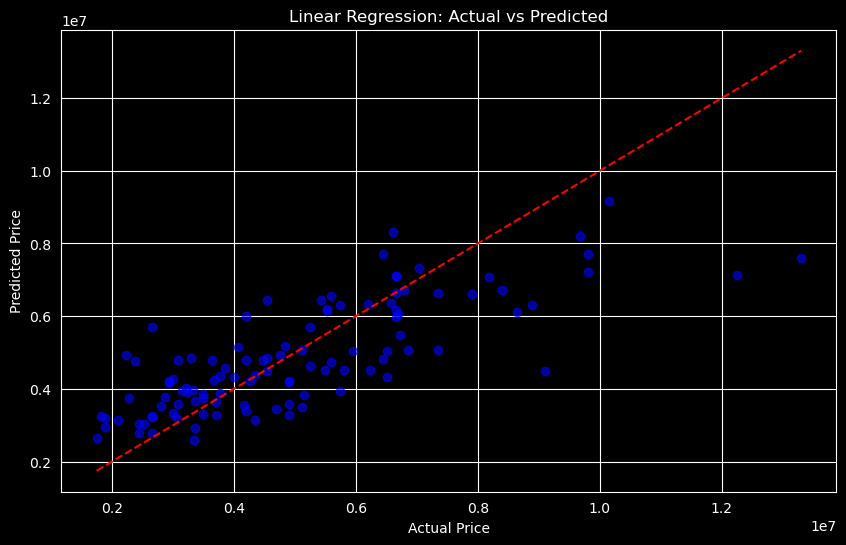

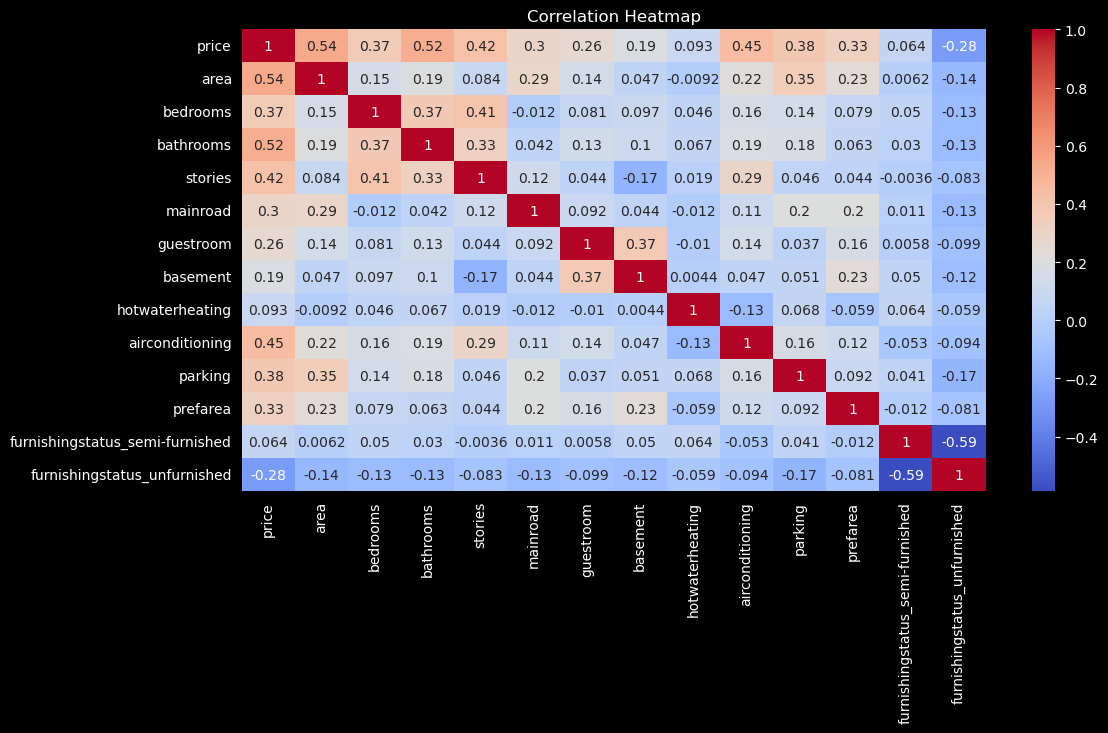

Bool variables:  2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished

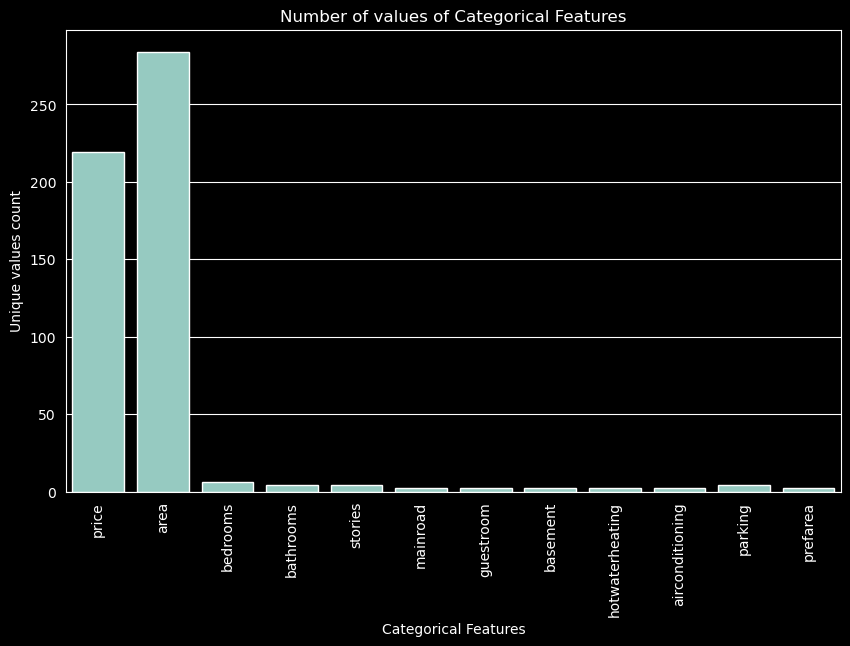

Accuracy: 0.7614678899082569
Precision: 0.5
Recall: 0.07692307692307693
F1: 0.13333333333333333
ROC-AUC: 0.6311399443929564
prefarea
0    0.765138
1    0.234862
Name: proportion, dtype: float64


<Figure size 800x600 with 0 Axes>

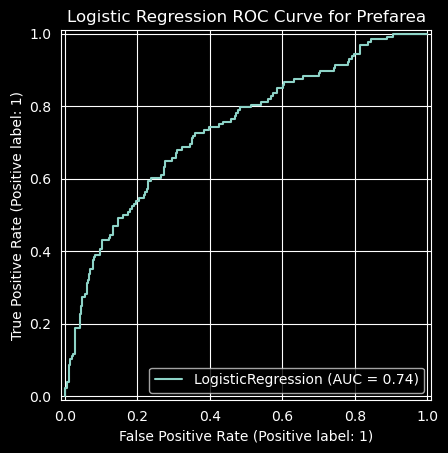

Describe of data: 
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

         mainroad   guestroom    basement  hotwaterheating  airconditioning  \
count  545.000000  545.000000  545.000000       545.000000       545.000000   
mean     0.858716    0.177982    0.350459         0.045872         0.315596   
std      0.348635    0.382849    0.477552         0.209399         0.465180   
min    

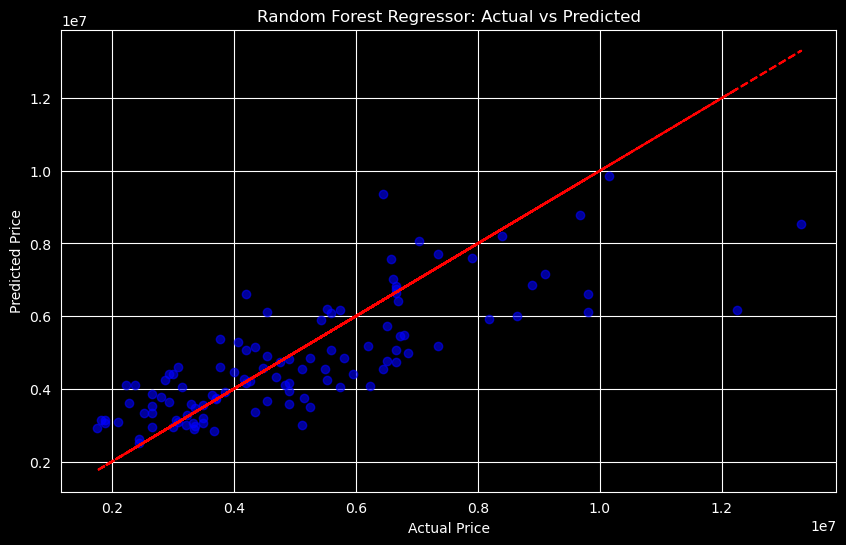

RMSE: 4.5918
R2 Score: nan
Coefficients:
Slope: 3.8571
Intercept: 57.4286
Predicted for 7 hours of study: 84.43


/home/denis/miniconda3/envs/ml_env/lib/python3.10/site-packages/sklearn/metrics/_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


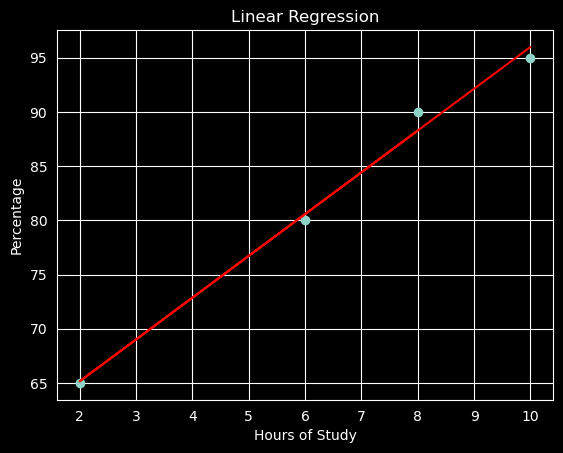

/home/denis/miniconda3/envs/ml_env/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning: [15:54:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "colesample_bytree" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Test RMSE: 2,103,518,298,112.00
Test R2 Score: 0.5838
Predicted model price: 4,363,703.00$
Actual price: 13,300,000.00


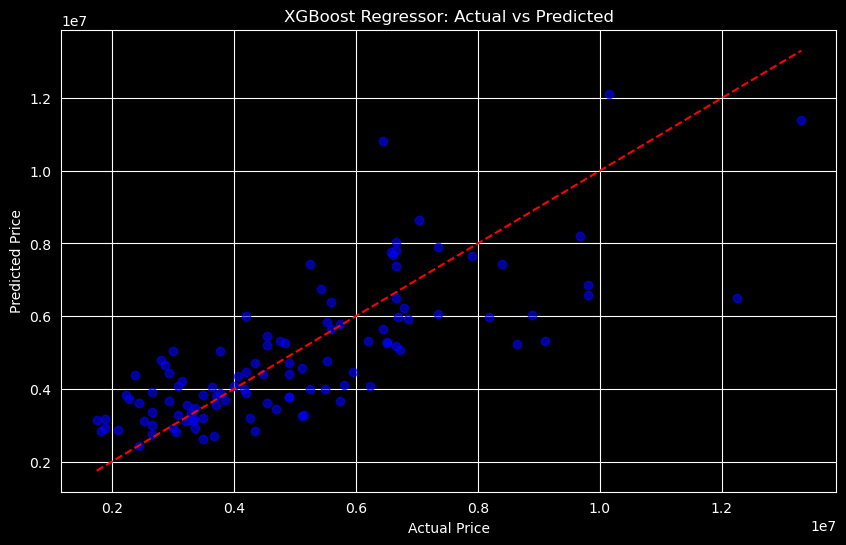

Test RMSE: 2,036,872,287,288.47
Test R2 Score: 0.5970
Predicted model price: 4,882,348.73$
Actual price: 13,300,000.00
Accuracy model score: 0.5970


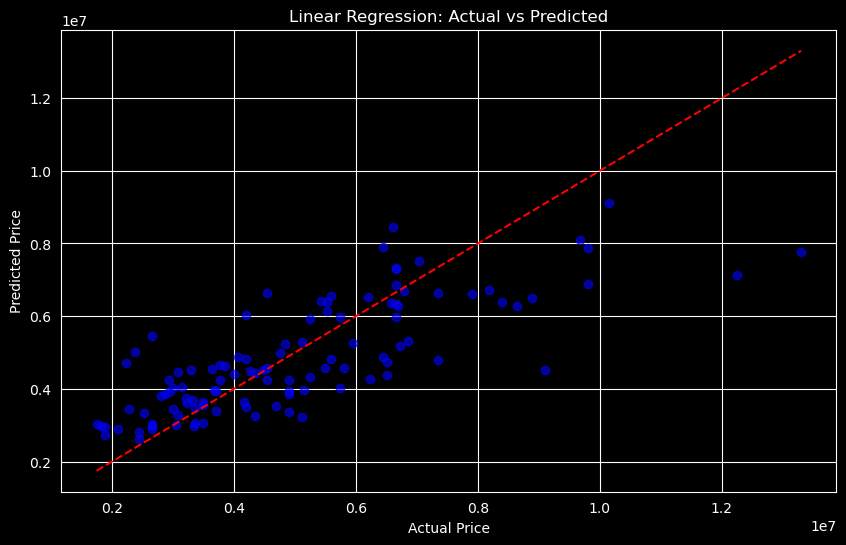

In [5]:
#Linear Regression Model, RMSError and R2 Score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features = ['area', 'bedrooms', 'bathrooms', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
            'prefarea']

X = data[features]
y = data['price']

import numpy as np
import pandas as pd
from matplotlib.pyplot import scatter
from numpy.random import logistic
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
#if file exist and if read it will return data

import os

for dirname, _, filenames in os.walk('data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

csv_path = 'data/Housing.csv'

if not os.path.exists(csv_path):
    raise FileNotFoundError(f"File '{csv_path}' was not found in the 'data' directory.")

data = pd.read_csv(csv_path)
data

 
def clean_name(name):
    return name.strip().title()

data.info()
#Convert yes to 1 and no to 0 in data
yes_no_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in yes_no_columns:
    data[col] = data[col].map({'yes': 1, 'no': 0})

data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)
data.head()
#Linear Regression Model, RMSError and R2 Score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

features = ['area', 'bedrooms', 'bathrooms', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
            'prefarea']

X = data[features]
y = data['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

rmse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)
print(f"Test RMSE: {rmse:,.2f}")
print(f"Test R2 Score: {r2:.4f}")
print(f"Predicted model price: {pred[0]:,.2f}$")
print(f"Actual price: {y_test[0]:,.2f}")
print(f"Accuracy model score: {model.score(X_test, y_test):.4f}")


plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

#EDA(Exploratory Data Analysis)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
#preprocessing data
bl = (data.dtypes == 'bool')
object_cols = list(bl[bl].index)
print("Bool variables: ", len(object_cols))



data.info()
#number of unique values in categorical features

unique_values = []

cat_cols = data.select_dtypes(include=['int']).columns.tolist()
for col in cat_cols:
    unique_values.append(data[col].nunique())

plt.figure(figsize=(10, 6))
plt.title('Number of values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=cat_cols, y=unique_values)
plt.ylabel('Unique values count')
plt.xlabel('Categorical Features')
plt.show()



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt


target = 'prefarea'
features = [c for c in data.columns if c not in [target, 'price']]
i = data[features]
p = data[target]

X_train, X_test, y_train, y_test = train_test_split(i, p, test_size=0.2, random_state=42, stratify=p)

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(p.value_counts(normalize=True))


plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(clf, scaler.transform(i), p)
plt.title('Logistic Regression ROC Curve for Prefarea')
plt.show()

print(f"Describe of data: \n{data.describe()}")
data.isnull().sum()
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

X = data[features]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
rmse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print(f"Test RMSE: {rmse:,.2f}")
print(f"Test R2 Score: {r2: .4f}")
print(f"Test MAE: {mae:,.2f}")
print(f"Predicted model price: {pred[0]:,.2f}$")
print(f"Actual price: {y_test[0]:,.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred, color='blue', alpha=0.6)
plt.plot(y_test, y_test, color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest Regressor: Actual vs Predicted')
plt.show()





#optional linear regression problem to predict outcome number of hours a student study

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

x = np.array([2, 4, 6, 8, 10]).reshape(-1, 1)
y = np.array([65, 75, 80, 90, 95])

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

r2 = r2_score(y_test, model.predict(x_test))
rmse = mean_squared_error(y_test, model.predict(x_test))


print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")
print("Coefficients:")
print(f"Slope: {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print(f"Predicted for 7 hours of study: {model.predict(np.array([[7]])).item():.2f}")

plt.scatter(x_train, y_train)
plt.plot(x_train, model.predict(x_train), color='red')
plt.xlabel('Hours of Study')
plt.ylabel('Percentage')
plt.title('Linear Regression')
plt.show()

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

features = ["area", "bedrooms", "bathrooms", "mainroad", "guestroom", "basement", "hotwaterheating",
            "airconditioning", "prefarea", "furnishingstatus_semi-furnished", "furnishingstatus_unfurnished"]

X = data[features]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb = XGBRegressor(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 4,
    subsample = 0.7,
    colesample_bytree = 0.8,
    random_state = 42
)

xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)

rmse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"Test RMSE: {rmse:,.2f}")
print(f"Test R2 Score: {r2:.4f}")
print(f"Predicted model price: {pred[0]:,.2f}$")
print(f"Actual price: {y_test[0]:,.2f}")
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('XGBoost Regressor: Actual vs Predicted')
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

rmse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)
print(f"Test RMSE: {rmse:,.2f}")
print(f"Test R2 Score: {r2:.4f}")
print(f"Predicted model price: {pred[0]:,.2f}$")
print(f"Actual price: {y_test[0]:,.2f}")
print(f"Accuracy model score: {model.score(X_test, y_test):.4f}")


plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()


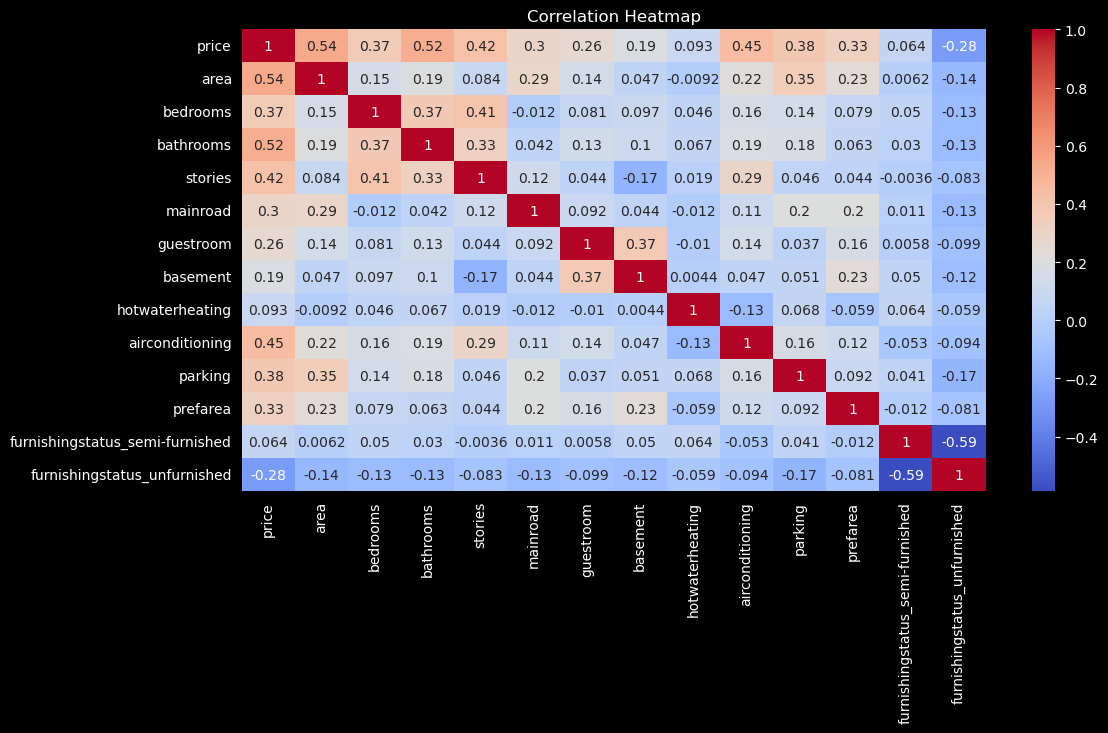

In [6]:
#EDA(Exploratory Data Analysis)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [7]:
#preprocessing data
bl = (data.dtypes == 'bool')
object_cols = list(bl[bl].index)
print("Bool variables: ", len(object_cols))



data.info()

Bool variables:  2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished

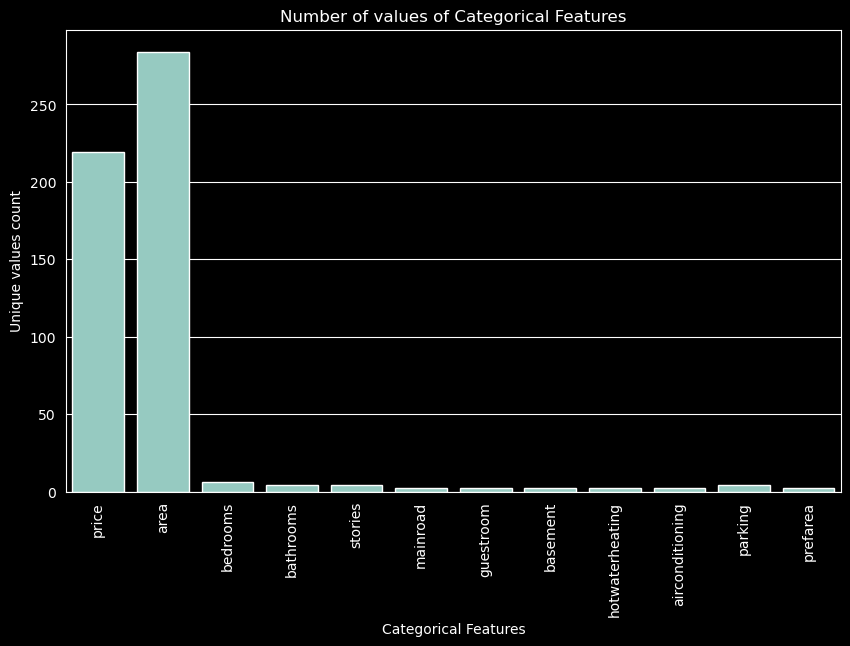

In [8]:
#number of unique values in categorical features

unique_values = []

cat_cols = data.select_dtypes(include=['int']).columns.tolist()
for col in cat_cols:
    unique_values.append(data[col].nunique())

plt.figure(figsize=(10, 6))
plt.title('Number of values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=cat_cols, y=unique_values)
plt.ylabel('Unique values count')
plt.xlabel('Categorical Features')
plt.show()




Task: Train a proper logistic regression classifier to predict prefarea using the existing features, with correct target encoding, train/test split, scaling, evaluation metrics, and a simple ROC-AUC plot.

Accuracy: 0.7614678899082569
Precision: 0.5
Recall: 0.07692307692307693
F1: 0.13333333333333333
ROC-AUC: 0.6311399443929564
prefarea
0    0.765138
1    0.234862
Name: proportion, dtype: float64


<Figure size 800x600 with 0 Axes>

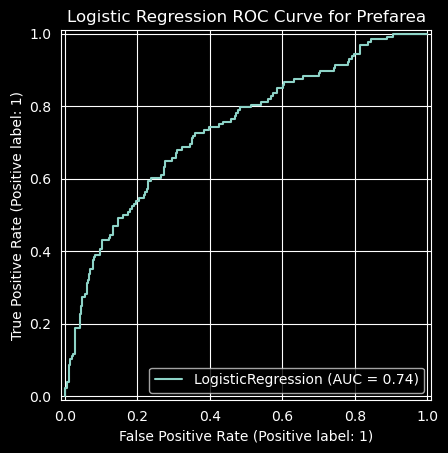

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt


target = 'prefarea'
features = [c for c in data.columns if c not in [target, 'price']]
i = data[features]
p = data[target]

X_train, X_test, y_train, y_test = train_test_split(i, p, test_size=0.2, random_state=42, stratify=p)

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
y_proba = clf.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, zero_division=0))
print("F1:", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(p.value_counts(normalize=True))


plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(clf, scaler.transform(i), p)
plt.title('Logistic Regression ROC Curve for Prefarea')
plt.show()


In [ ]:
print(f"Describe of data: \n{data.describe()}")
data.isnull().sum()

Describe of data: 
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

         mainroad   guestroom    basement  hotwaterheating  airconditioning  \
count  545.000000  545.000000  545.000000       545.000000       545.000000   
mean     0.858716    0.177982    0.350459         0.045872         0.315596   
std      0.348635    0.382849    0.477552         0.209399         0.465180   
min    

price                              0
area                               0
bedrooms                           0
bathrooms                          0
stories                            0
mainroad                           0
guestroom                          0
basement                           0
hotwaterheating                    0
airconditioning                    0
parking                            0
prefarea                           0
furnishingstatus_semi-furnished    0
furnishingstatus_unfurnished       0
dtype: int64

Test RMSE: 1,412,059.53
Test R2 Score:  0.6055
Test MAE: 1,020,378.00
Predicted model price: 5,289,900.00$
Actual price: 13,300,000.00


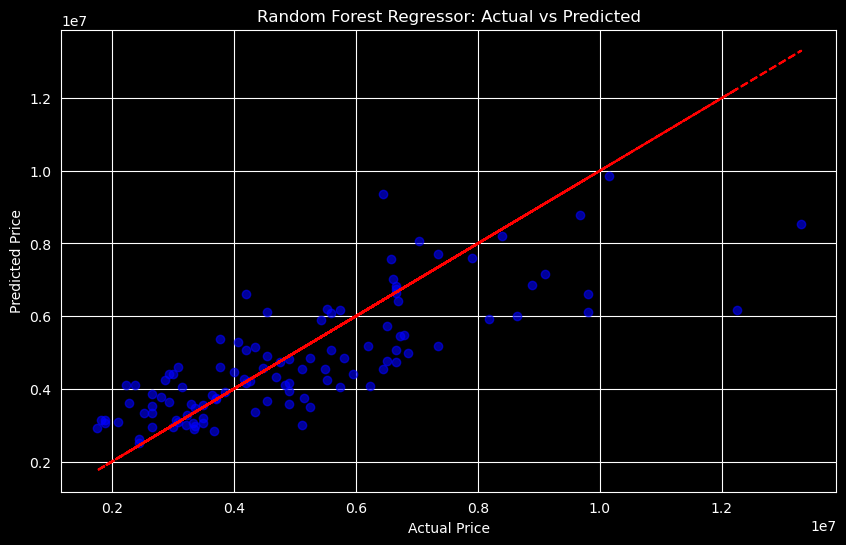

In [11]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import numpy as np 

X = data[features]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print(f"Test RMSE: {rmse:,.2f}")
print(f"Test R2 Score: {r2: .4f}")
print(f"Test MAE: {mae:,.2f}")
print(f"Predicted model price: {pred[0]:,.2f}$")
print(f"Actual price: {y_test[0]:,.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred, color='blue', alpha=0.6)
plt.plot(y_test, y_test, color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest Regressor: Actual vs Predicted')
plt.show()






Test RMSE: 1,479,462.21
Test R2 Score: 0.5670
Predicted model price: 4,443,557.50$
Actual price: 13,300,000.00


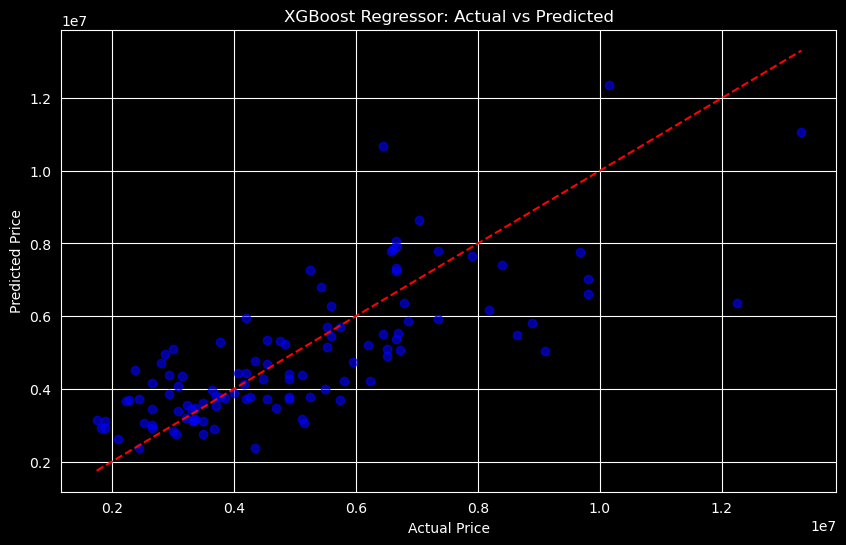

In [13]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

features = ["area", "bedrooms", "bathrooms", "mainroad", "guestroom", "basement", "hotwaterheating",
            "airconditioning", "prefarea", "furnishingstatus_semi-furnished", "furnishingstatus_unfurnished"]

X = data[features]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb = XGBRegressor(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 4,
    subsample = 0.7,
    colsample_bytree = 0.8,
    random_state = 42
)

xgb.fit(X_train, y_train)
pred = xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print(f"Test RMSE: {rmse:,.2f}")
print(f"Test R2 Score: {r2:.4f}")
print(f"Predicted model price: {pred[0]:,.2f}$")
print(f"Actual price: {y_test[0]:,.2f}")
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred, color='blue', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('XGBoost Regressor: Actual vs Predicted')
plt.show()
